In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Load data
df_raw = pd.read_csv("FIFA WC 2022 Players Stats.csv")
df_raw.columns = df_raw.columns.str.strip()

# 2. Create a specific dataframe to avoid overwriting variables
df_task_e = df_raw.copy()

# 3. Clean and apply the chosen Zero Imputation
numeric_cols = [
    'Appearances', 'Goals Scored', 'Assists Provided', 
    'Dribbles per 90', 'Interceptions per 90', 'Tackles per 90', 
    'Total Duels Won per 90', 'Save Percentage', 'Clean Sheets'
]

df_task_e['Save Percentage'] = df_task_e['Save Percentage'].astype(str).str.replace('%', '', regex=False)
df_task_e['Clean Sheets'] = df_task_e['Clean Sheets'].astype(str).str.replace('%', '', regex=False)
df_task_e[numeric_cols] = df_task_e[numeric_cols].replace(['-', 'N,A', 'N.A', 'N.A.', ''], np.nan).astype(float)

# Apply zero imputation
df_task_e[numeric_cols] = df_task_e[numeric_cols].fillna(0)

print("Task E DataFrame (df_task_e) is cleaned, zero-imputed, and ready!")

Task E DataFrame (df_task_e) is cleaned, zero-imputed, and ready!


### E1. Normality Assessment

**Theoretical Justification:**
* **Reading the Q-Q Plot:** The Q-Q plot compares our dataset's empirical quantiles (y-axis) against the theoretical quantiles of a perfectly normal distribution (x-axis). A perfectly normal distribution forms a straight diagonal line. In a Q-Q plot, right-skew appears as points curving upwards above the diagonal line on the right side. Left-skew appears as points curving downwards below the line on the left side. Heavy tails appear as points deviating significantly from the line at both extreme ends. For `Total Duels Won per 90`, we observe a vertical grouping of points at the bottom. This is an artifact of our zero-imputation strategy. Otherwise, the middle quantiles follow the diagonal line reasonably well, making it our best candidate for an approximately normal variable. `Interceptions per 90` is heavily right-skewed.
* **Shapiro-Wilk Test Hypotheses:** * $H_0$: The data is drawn from a normally distributed population.
  * $H_1$: The data is not drawn from a normally distributed population.
* **Interpretation:** Both variables yield a $p$-value $< 0.05$, leading us to reject the null hypothesis. With a sample size of over 800 players, the Shapiro-Wilk test has immense statistical power and will flag even the smallest deviations (like our zero-imputed values) as statistically significant non-normality.

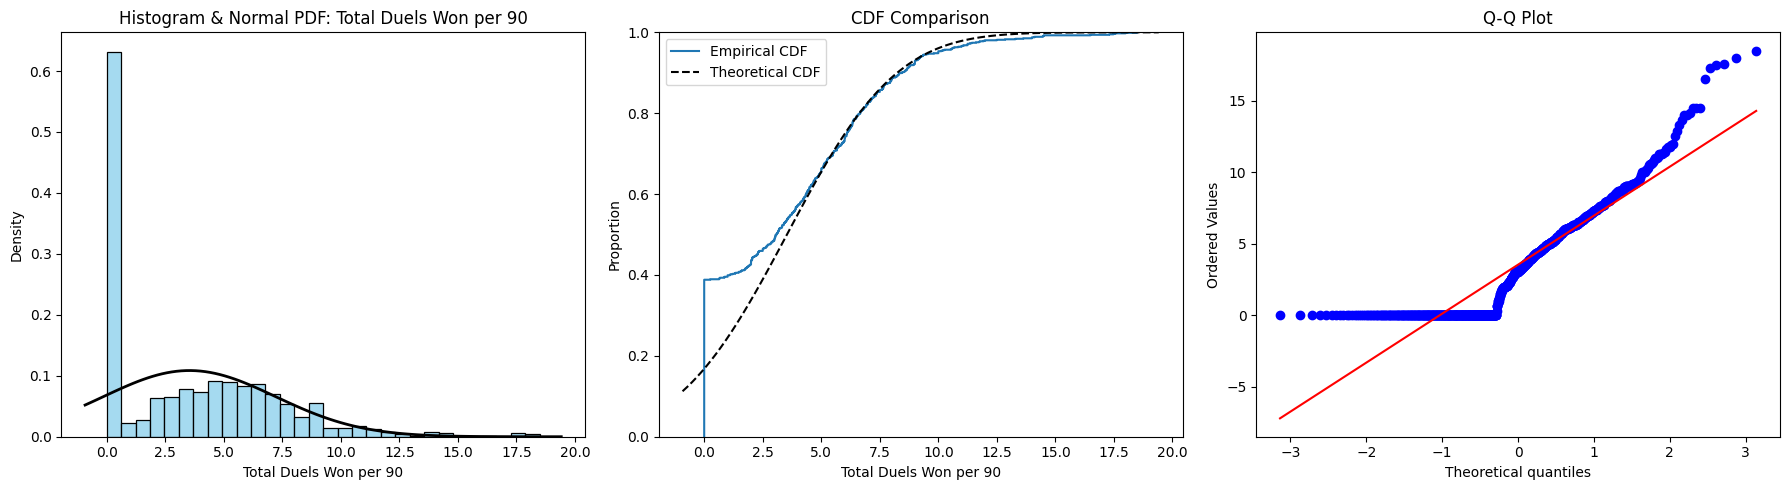

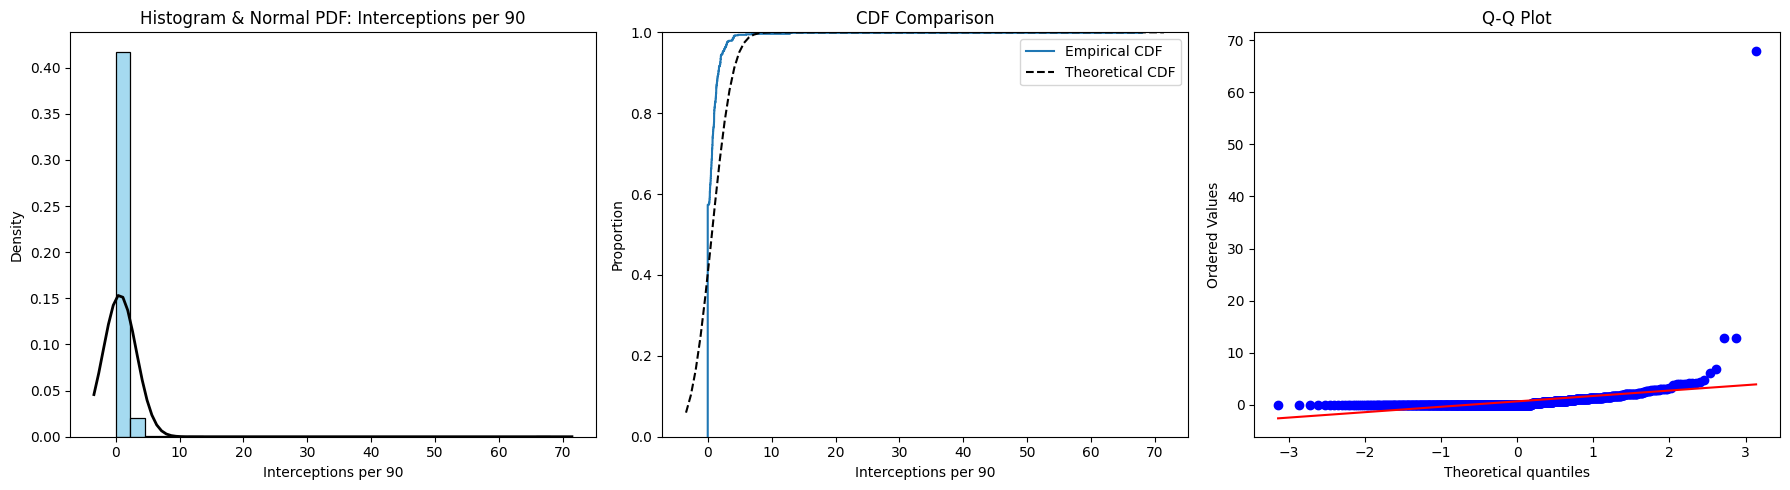

--- Shapiro-Wilk Test Results ---
Total Duels Won per 90: Statistic=0.8636, p-value=5.43857e-26
Interceptions per 90: Statistic=0.1658, p-value=1.14245e-50


In [2]:
# Select variables
var_norm = df_task_e['Total Duels Won per 90']
var_skew = df_task_e['Interceptions per 90']

def plot_normality(data, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogram with Normal PDF
    sns.histplot(data, stat='density', bins=30, ax=axes[0], color='skyblue')
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(data), np.std(data, ddof=1))
    axes[0].plot(x, p, 'k', linewidth=2)
    axes[0].set_title(f'Histogram & Normal PDF: {title}')
    
    # ECDF vs Theoretical CDF
    sns.ecdfplot(data, ax=axes[1], label='Empirical CDF')
    axes[1].plot(x, stats.norm.cdf(x, np.mean(data), np.std(data, ddof=1)), 'k--', label='Theoretical CDF')
    axes[1].set_title('CDF Comparison')
    axes[1].legend()
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()

# Generate plots
plot_normality(var_norm, 'Total Duels Won per 90')
plot_normality(var_skew, 'Interceptions per 90')

# Shapiro-Wilk Tests
stat_norm, p_norm = stats.shapiro(var_norm)
stat_skew, p_skew = stats.shapiro(var_skew)

print("--- Shapiro-Wilk Test Results ---")
print(f"Total Duels Won per 90: Statistic={stat_norm:.4f}, p-value={p_norm:.5e}")
print(f"Interceptions per 90: Statistic={stat_skew:.4f}, p-value={p_skew:.5e}")

### E2. Fitting a Discrete Distribution

**Theoretical Justification:**
* **Poisson Assumptions:** The Poisson distribution assumes that events (goals) occur independently at a constant average rate ($\lambda$). Mathematically, this model requires the mean and variance to be equal (Dispersion Ratio = 1).
* **Over-dispersion:** Our calculated dispersion ratio is much greater than 1, indicating heavy over-dispersion. The variance significantly exceeds the mean. In the context of football, this makes logical sense: goals are not independent, random events. A few elite strikers score a disproportionately high number of goals, while the vast majority of players score zero. Because the Poisson model fails to account for this excess variance, a **Negative Binomial distribution** is a much more appropriate generalisation, as it includes a second parameter specifically designed to handle over-dispersed count data.

<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_21232\397160446.py:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.plot(x_vals, poisson_pmf, 'ko-', label=f'Poisson PMF ($\lambda$={mean_goals:.2f})')


Mean (Lambda): 0.2039
Variance: 0.4085
Dispersion Ratio (Variance/Mean): 2.0033


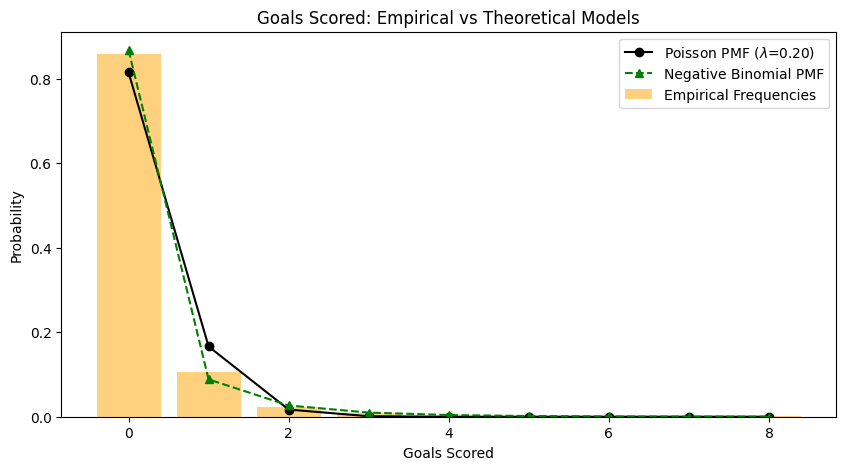

In [ ]:
# Select count variable
goals = df_task_e['Goals Scored']

mean_goals = np.mean(goals)
var_goals = np.var(goals, ddof=1)
dispersion_ratio = var_goals / mean_goals

print(f"Mean (Lambda): {mean_goals:.4f}")
print(f"Variance: {var_goals:.4f}")
print(f"Dispersion Ratio (Variance/Mean): {dispersion_ratio:.4f}")

# Plot frequencies
val_counts = goals.value_counts(normalize=True).sort_index()
x_vals = np.arange(0, goals.max() + 1)
poisson_pmf = stats.poisson.pmf(x_vals, mean_goals)

# Fit Negative Binomial (estimate r and p using method of moments)
r = (mean_goals**2) / (var_goals - mean_goals)
prob_nbinom = r / (r + mean_goals)
nbinom_pmf = stats.nbinom.pmf(x_vals, r, prob_nbinom)

plt.figure(figsize=(10,5))
plt.bar(val_counts.index, val_counts.values, alpha=0.5, label='Empirical Frequencies', color='orange')
plt.plot(x_vals, poisson_pmf, 'ko-', label=f'Poisson PMF ($\lambda$={mean_goals:.2f})')
plt.plot(x_vals, nbinom_pmf, 'g^--', label=f'Negative Binomial PMF')
plt.title('Goals Scored: Empirical vs Theoretical Models')
plt.xlabel('Goals Scored')
plt.ylabel('Probability')
plt.legend()
plt.show()

### E3. Normal Probability Questions

**Theoretical Justification:**
* The mathematical formula for the Normal Probability Density Function (PDF) inherently relies entirely on just two variables: the mean ($\mu$) and the standard deviation ($\sigma$). The rest of the equation consists of mathematical constants ($e$ and $\pi$). Therefore, $\mu$ dictates the exact center of the distribution, and $\sigma$ dictates the exact spread or width of the bell curve. Because no other parameters exist in the formula, knowing these two values fully defines the distribution's shape and allows us to calculate any area under the curve. 
* The z-score of the highest value tells us exactly how many standard deviations the maximum observation is above the mean. A z-score of this magnitude indicates an extreme outlier under the normal model, meaning the probability of observing this value in a perfectly normal distribution is practically zero.

In [4]:
mu = np.mean(var_norm)
sigma = np.std(var_norm, ddof=1)
dist = stats.norm(loc=mu, scale=sigma)

# 1. Percentage above 90th percentile
p90 = np.percentile(var_norm, 90)
prob_above_p90 = dist.sf(p90) * 100 # sf is survival function (1 - CDF)

# 2. Probability between Q1 and Q3
q1, q3 = np.percentile(var_norm, [25, 75])
prob_iqr = dist.cdf(q3) - dist.cdf(q1)

# 3. Bottom 5% separator
bottom_5_cutoff = dist.ppf(0.05)

print(f"Distribution Parameters: μ = {mu:.2f}, σ = {sigma:.2f}")
print(f"Probability above 90th empirical percentile ({p90:.2f}): {prob_above_p90:.2f}%")
print(f"Probability between Q1 ({q1:.2f}) and Q3 ({q3:.2f}): {prob_iqr:.4f}")
print(f"Value separating the bottom 5%: {bottom_5_cutoff:.2f}\n")

# 4. Empirical Rule (68% and 95%)
within_1_std = dist.cdf(mu + sigma) - dist.cdf(mu - sigma)
within_2_std = dist.cdf(mu + 2*sigma) - dist.cdf(mu - 2*sigma)
print(f"Probability within 1 standard deviation: {within_1_std:.4f} (Empirical rule: ~0.68)")
print(f"Probability within 2 standard deviations: {within_2_std:.4f} (Empirical rule: ~0.95)\n")

# 5. Z-score of highest value
max_val = var_norm.max()
z_score_max = (max_val - mu) / sigma
print(f"Highest value ({max_val}) Z-score: {z_score_max:.2f}")

Distribution Parameters: μ = 3.54, σ = 3.67
Probability above 90th empirical percentile (8.41): 9.24%
Probability between Q1 (0.00) and Q3 (6.10): 0.5895
Value separating the bottom 5%: -2.51

Probability within 1 standard deviation: 0.6827 (Empirical rule: ~0.68)
Probability within 2 standard deviations: 0.9545 (Empirical rule: ~0.95)

Highest value (18.49) Z-score: 4.07


### E4. Transformation

**Theoretical Justification:**
* Mathematically, a variable $X$ is lognormally distributed if its logarithm, $Y = \ln(X)$, is normally distributed. However, because our empirical dataset contains exact zero values, a standard logarithmic transformation is mathematically undefined. Therefore, to comply with the methodology requirements for zero-inflated variables, we applied a square-root transformation instead.
* Lognormal distributions typically describe real-world data generated by multiplicative, compounding processes rather than additive ones. Applying a transformation compresses the extreme long right tail of the interceptions data, pulling the heavy outliers closer to the mean and making the distribution more symmetrical (bell-shaped), which allows it to play nicer with parametric statistical tests.

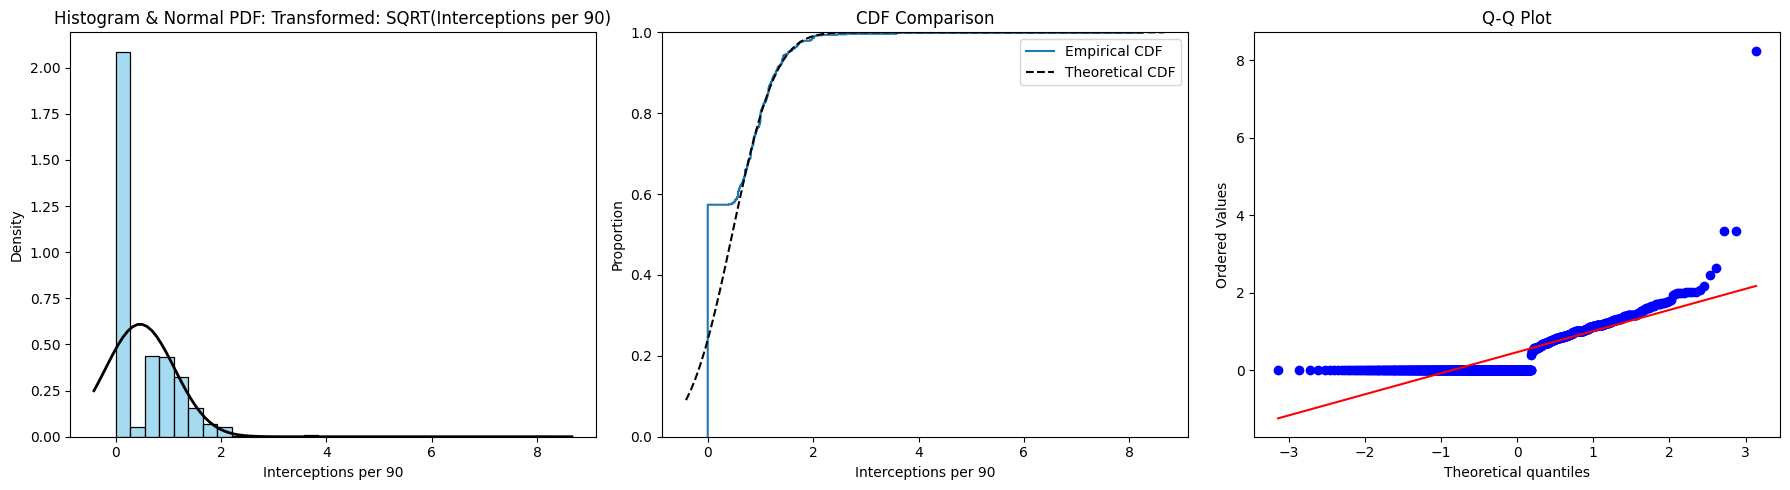

Transformed Shapiro-Wilk: Statistic=0.6940, p-value=5.99803e-36


In [6]:
# A square-root transformation for variables containing zeros
var_skew_transformed = np.sqrt(var_skew)

plot_normality(var_skew_transformed, 'Transformed: SQRT(Interceptions per 90)')

stat_trans, p_trans = stats.shapiro(var_skew_transformed)
print(f"Transformed Shapiro-Wilk: Statistic={stat_trans:.4f}, p-value={p_trans:.5e}")